## Plotting the raw synaptic metrics in heatmap across metric x hippocampal lamina
#### Input: output of `04_lmem.R`
#### Description: 
#####   (1) data frame operations
#####   (2) plotting
#### Date: Nov 2025

In [16]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

In [17]:
# Candidate to make the heatmap of
experiment = "oe"
protein = "VCAM1"

In [18]:
# order to show the metrics and hippocampal layers

metric_order = [
    "presynapse_image_mfi", 
    "pre_staining_area_um2",
    "pre_puncta_density_per_100_um2",
    "pre_mean_puncta_size_um2",
    "postsynapse_image_mfi",
    "post_staining_area_um2",
    "post_puncta_density_per_100_um2",
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ]
if experiment == "crispr":
    vglut1_hippocampal_layer_order = [
        "CA1 SO",
        "CA1 SR",
        "CA1 SLM",
        "CA3 SO",
        "CA3 SL",
        "CA3 SR",
        "DG ML",
        "DG Hilus"
        ]

    vgat_hippocampal_layer_order = [
        "CA1 SO",
        "CA1 SR",
        "CA1 SLM",
        "CA3 SO",
        "CA3 SL",
        "CA3 SR",
        "DG ML",
        "DG Hilus"
        ]
elif experiment == "oe":
    vglut1_hippocampal_layer_order = [
        "CA1 SO",
        "CA1 SR",
        "CA1 SLM",
        "CA3 SO",
        "CA3 SL",
        "CA3 SR"
        ]

    vgat_hippocampal_layer_order = [
        "CA1 SO",
        "CA1 SR",
        "CA1 SLM",
        "CA3 SO",
        "CA3 SL",
        "CA3 SR"
        ]

In [19]:
#reading in the VGLUT1-PSD95 data
if experiment == "crispr":
    file_path_vglut1 = f"/Volumes/Intenso/image-analysis/synapse-counting/results_202512/{protein}_VGLUT1-PSD95_lmem_analysis_results.csv"
elif experiment == "oe":
    file_path_vglut1 = "/Volumes/Intenso/image-analysis/synapse-counting-oe/results_202604/VCAM1_VGLUT1-PSD95_oe_lmem_analysis_results.csv"
df_vglut1 = pd.read_csv(file_path_vglut1)
df_vglut1.head(10)

,hippocampal_layer,contrast,estimate,SE,df,z.ratio,p.value,Mean_HA-VCAM1,Mean_Lck-GFP,p.value.adj,analyzed_metric,analyzed_protein
0,CA1 SLM,(HA-VCAM1) - (Lck-GFP),0.656818,0.716366,inf,0.916875,0.359208,8.634656,7.977838,0.538812,local_peak_colocalized_spots,VCAM1
1,CA1 SO,(HA-VCAM1) - (Lck-GFP),-0.422533,0.716366,inf,-0.589828,0.555306,6.018409,6.440942,0.666367,local_peak_colocalized_spots,VCAM1
2,CA1 SR,(HA-VCAM1) - (Lck-GFP),-0.205831,0.716366,inf,-0.287326,0.773862,10.611205,10.817036,0.773862,local_peak_colocalized_spots,VCAM1
3,CA3 SL,(HA-VCAM1) - (Lck-GFP),1.127187,0.716366,inf,1.573479,0.115608,6.021271,4.894084,0.529383,local_peak_colocalized_spots,VCAM1
4,CA3 SO,(HA-VCAM1) - (Lck-GFP),0.812872,0.716366,inf,1.134716,0.256494,2.717035,1.904163,0.529383,local_peak_colocalized_spots,VCAM1
5,CA3 SR,(HA-VCAM1) - (Lck-GFP),0.799013,0.716366,inf,1.115371,0.264692,8.134068,7.335055,0.529383,local_peak_colocalized_spots,VCAM1
6,CA1 SLM,(HA-VCAM1) - (Lck-GFP),-0.014556,0.019193,inf,-0.758383,0.448221,0.166290,0.180846,0.844256,overlap_coeff,VCAM1
7,CA1 SO,(HA-VCAM1) - (Lck-GFP),0.001083,0.019193,inf,0.056413,0.955013,0.183583,0.182500,0.955013,overlap_coeff,VCAM1
8,CA1 SR,(HA-VCAM1) - (Lck-GFP),0.003562,0.019193,inf,0.185597,0.852761,0.158417,0.154855,0.955013,overlap_coeff,VCAM1
9,CA3 SL,(HA-VCAM1) - (Lck-GFP),0.012683,0.019193,inf,0.660837,0.508717,0.206920,0.194237,0.844256,overlap_coeff,VCAM1


In [20]:
# get the df for adj p values
df_vglut1_adj_p_values = df_vglut1[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vglut1_p_value = df_vglut1_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vglut1_p_value_ordered = df_wide_vglut1_p_value[vglut1_hippocampal_layer_order]
df_wide_vglut1_p_value_ordered.head(12)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR
analyzed_metric,,,,,,
presynapse_image_mfi,0.256327,0.256327,0.673419,0.256327,0.256327,0.535855
pre_staining_area_um2,0.977837,0.977837,0.977837,0.977837,0.977837,0.977837
pre_puncta_density_per_100_um2,0.955401,0.955401,0.955401,0.955401,0.890687,0.955401
pre_mean_puncta_size_um2,0.894421,0.894421,0.894421,0.894421,0.894421,0.894421
postsynapse_image_mfi,0.812791,0.811612,0.449388,0.449388,0.097738,0.080810
post_staining_area_um2,0.968961,0.968961,0.968961,0.410685,0.417627,0.968961
post_puncta_density_per_100_um2,0.941168,0.941168,0.941168,0.444707,0.770610,0.941168
post_mean_puncta_size_um2,0.990246,0.930223,0.930223,0.513598,0.012601,0.930223
local_peak_colocalized_spots,0.666367,0.773862,0.538812,0.529383,0.529383,0.529383


In [25]:
# get the df for log2 fold change
df_vglut1_log2_fc = df_vglut1[["hippocampal_layer", "estimate", "analyzed_metric"]]
df_wide_vglut1_log2_fc = df_vglut1_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="estimate").reindex(metric_order)
df_wide_vglut1_log2_fc_ordered = df_wide_vglut1_log2_fc[vglut1_hippocampal_layer_order]
if (experiment == "crispr" and protein == "VCAM1"):
    df_wide_vglut1_log2_fc_ordered = -df_wide_vglut1_log2_fc_ordered
else: 
    pass
df_wide_vglut1_log2_fc_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR
analyzed_metric,,,,,,
presynapse_image_mfi,-0.154399,-0.141770,-0.035959,-0.116835,-0.124881,-0.064945
pre_staining_area_um2,-0.202804,-0.060330,-0.121214,-0.039539,-0.522485,0.010451
pre_puncta_density_per_100_um2,-0.173007,-0.043836,-0.074182,-0.018799,-0.422748,-0.016361
pre_mean_puncta_size_um2,-0.003873,-0.001754,-0.005410,-0.003552,-0.015201,0.003092
postsynapse_image_mfi,-0.026960,-0.047523,0.131802,0.118085,0.243298,0.281310
post_staining_area_um2,-0.025014,0.044370,0.012935,0.605674,0.491554,0.174399
post_puncta_density_per_100_um2,-0.019787,0.021327,0.034851,0.478808,0.303985,0.126875
post_mean_puncta_size_um2,0.000084,0.001965,-0.002038,0.009414,0.021159,0.004987
local_peak_colocalized_spots,-0.422533,-0.205831,0.656818,0.812872,1.127187,0.799013


In [26]:
# reading in the VGAT-GEPH dataset
if experiment == "crispr":
    vgat_results_file = f"/Volumes/Intenso/image-analysis/synapse-counting/results_202512/{protein}_VGAT-GEPH_lmem_analysis_results.csv"
elif experiment == "oe":
    vgat_results_file = "/Volumes/Intenso/image-analysis/synapse-counting-oe/results_202604/VCAM1_VGAT-GEPH_oe_lmem_analysis_results.csv"
df_vgat = pd.read_csv(vgat_results_file)
df_vgat.head(10)

,hippocampal_layer,contrast,estimate,SE,df,z.ratio,p.value,Mean_HA-VCAM1,Mean_Lck-GFP,p.value.adj,analyzed_metric,analyzed_protein
0,CA1 SLM,(HA-VCAM1) - (Lck-GFP),0.060940,0.357894,inf,0.170273,0.864795,6.559036,6.498097,0.864795,local_peak_colocalized_spots,VCAM1
1,CA1 SO,(HA-VCAM1) - (Lck-GFP),-0.065191,0.357894,inf,-0.182152,0.855464,4.184726,4.249917,0.864795,local_peak_colocalized_spots,VCAM1
2,CA1 SR,(HA-VCAM1) - (Lck-GFP),-0.428456,0.357894,inf,-1.197160,0.231244,5.144234,5.572690,0.346866,local_peak_colocalized_spots,VCAM1
3,CA3 SL,(HA-VCAM1) - (Lck-GFP),-0.541825,0.357894,inf,-1.513927,0.130044,2.662409,3.204234,0.260089,local_peak_colocalized_spots,VCAM1
4,CA3 SO,(HA-VCAM1) - (Lck-GFP),-0.985927,0.357894,inf,-2.754806,0.005873,4.207997,5.193924,0.035236,local_peak_colocalized_spots,VCAM1
5,CA3 SR,(HA-VCAM1) - (Lck-GFP),-0.868446,0.357894,inf,-2.426547,0.015243,4.713180,5.581626,0.045730,local_peak_colocalized_spots,VCAM1
6,CA1 SLM,(HA-VCAM1) - (Lck-GFP),0.018156,0.016713,inf,1.086304,0.277345,0.125653,0.107497,0.832034,overlap_coeff,VCAM1
7,CA1 SO,(HA-VCAM1) - (Lck-GFP),-0.011110,0.016713,inf,-0.664747,0.506212,0.192763,0.203873,0.849100,overlap_coeff,VCAM1
8,CA1 SR,(HA-VCAM1) - (Lck-GFP),-0.003180,0.016713,inf,-0.190267,0.849100,0.157821,0.161001,0.849100,overlap_coeff,VCAM1
9,CA3 SL,(HA-VCAM1) - (Lck-GFP),-0.059722,0.016713,inf,-3.573314,0.000352,0.106541,0.166263,0.002115,overlap_coeff,VCAM1


In [27]:
# get the df with adj pvalues
df_vgat_adj_p_values = df_vgat[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vgat_p_value = df_vgat_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vgat_p_value_ordered = df_wide_vgat_p_value[vglut1_hippocampal_layer_order]
df_wide_vgat_p_value_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR
analyzed_metric,,,,,,
presynapse_image_mfi,0.036632,0.009212,0.177606,0.000010,0.001596,0.000022
pre_staining_area_um2,0.922793,0.922793,0.187479,0.529927,0.529927,0.529927
pre_puncta_density_per_100_um2,0.901094,0.878279,0.286893,0.780701,0.780701,0.683831
pre_mean_puncta_size_um2,0.958646,0.752470,0.371909,0.106028,0.371909,0.562015
postsynapse_image_mfi,0.968928,0.939116,0.576960,0.939116,0.968928,0.939116
post_staining_area_um2,0.992376,0.992376,0.992376,0.992376,0.992376,0.941652
post_puncta_density_per_100_um2,0.884305,0.884305,0.884305,0.884305,0.884305,0.884305
post_mean_puncta_size_um2,0.842461,0.869444,0.842461,0.869444,0.842461,0.842461
local_peak_colocalized_spots,0.864795,0.346866,0.864795,0.035236,0.260089,0.045730


In [28]:
# get the df with log2 fold change
df_vgat_adj_log2_fc = df_vgat[["hippocampal_layer", "estimate", "analyzed_metric"]]
df_wide_vgat_log2_fc = df_vgat_adj_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="estimate").reindex(metric_order)
df_wide_vgat_log2_fc_ordered = df_wide_vgat_log2_fc[vglut1_hippocampal_layer_order]
if (experiment == "crispr" and protein == "VCAM1"):
    df_wide_vgat_log2_fc_ordered = -df_wide_vgat_log2_fc_ordered
else: 
    pass
df_wide_vgat_log2_fc_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR
analyzed_metric,,,,,,
presynapse_image_mfi,-0.130679,-0.165533,-0.081443,-0.289240,-0.202582,-0.270871
pre_staining_area_um2,0.033894,0.071811,0.753268,-0.352227,-0.324623,0.328902
pre_puncta_density_per_100_um2,0.039565,0.109069,0.630027,-0.204583,-0.214722,0.383832
pre_mean_puncta_size_um2,0.000278,-0.002609,0.007103,-0.012740,-0.007236,-0.004767
postsynapse_image_mfi,0.002906,-0.047611,0.124109,-0.036347,-0.007161,-0.046668
post_staining_area_um2,0.032182,-0.290586,0.024082,0.003675,-0.229724,0.544437
post_puncta_density_per_100_um2,0.090715,-0.307012,0.107393,-0.042974,-0.112742,0.384554
post_mean_puncta_size_um2,-0.006496,0.001840,-0.008963,0.003850,-0.010243,0.012196
local_peak_colocalized_spots,-0.065191,-0.428456,0.060940,-0.985927,-0.541825,-0.868446


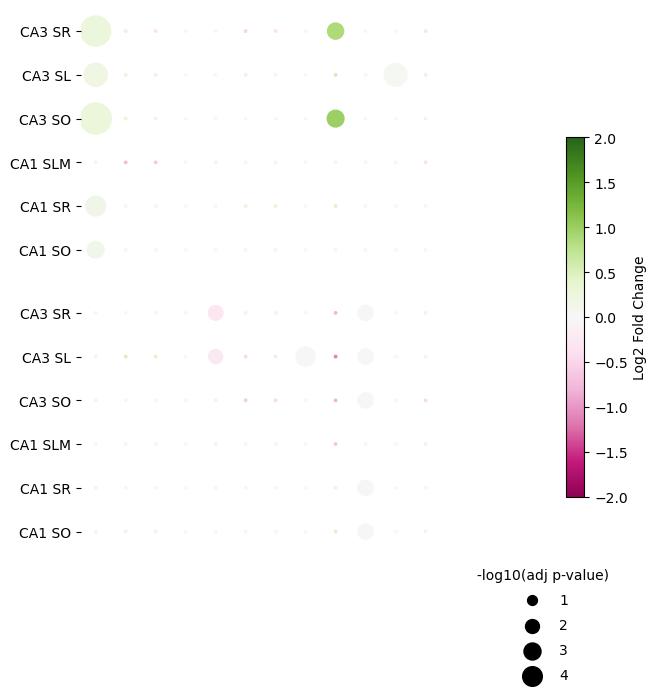

In [12]:
# Set up the figure
fig = plt.figure(figsize=(6.5, 8))

# Create a grid for the main plots and the legend
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1], height_ratios=[1, 1, 0.2], hspace=0.1, wspace=0.1)

# Data and parameters for each plot
data_sets = [
    (df_wide_vgat_p_value_ordered, df_wide_vgat_log2_fc_ordered, vgat_hippocampal_layer_order),
    (df_wide_vglut1_p_value_ordered, df_wide_vglut1_log2_fc_ordered, vglut1_hippocampal_layer_order)
]
titles = ['VGAT', 'VGLUT1']

# Create subplots for the main plots
axes = [fig.add_subplot(gs[i, 0]) for i in range(2)]

for i, (ax, (df_p_value, df_log2_fc, hippocampal_layer_order)) in enumerate(zip(axes, data_sets)):
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Flatten the data
    x_vals = np.repeat(range(len(metric_order)), len(hippocampal_layer_order))
    y_vals = np.tile(range(len(hippocampal_layer_order)), len(metric_order))
    sizes = df_p_value.values.flatten()
    sizes_log = -np.log10(sizes) * 100
    colors = df_log2_fc.values.flatten()

    # Apply cutoff
    cutoff = 1
    sizes_log[sizes_log < (cutoff * 100)] = 3

    # Create scatter plot
    norm = Normalize(vmin=-2, vmax=2)
    scatter = ax.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='PiYG', norm=norm)
    
    # Adjust x and y limits to avoid cutting off points
    ax.set_xlim(-0.5, len(metric_order) - 0.5)
    ax.set_ylim(-0.5, len(hippocampal_layer_order) - 0.5)
    
    # Set y ticks for each plot
    ax.set_yticks(range(len(hippocampal_layer_order)))
    ax.set_yticklabels(hippocampal_layer_order)

    # Only set x ticks for the bottom plot
    if i == 2:  # Bottom plot
        ax.set_xticks(range(len(metric_order)))
        ax.set_xticklabels(metric_order, rotation=90)
    else:
        ax.set_xticks([])

    # Set title for each subplot
    #ax.set_title(titles[i], y=1.0, pad=-14)

# Create a subplot for the legends
legend_ax = fig.add_subplot(gs[:, 1])
legend_ax.axis('off')

# Add a colorbar
cbar = fig.colorbar(scatter, ax=legend_ax, shrink=0.8, aspect=20, pad=0.05)
cbar.set_label("Log2 Fold Change")

# Create a legend for dot sizes
size_legend_labels = [1, 2, 3, 4]
size_legend = [plt.scatter([], [], s=size*50, edgecolor='black', facecolor='black') for size in size_legend_labels]
legend_ax.legend(size_legend, [f'{label}' for label in size_legend_labels],
                 title='-log10(adj p-value)', loc='center left', bbox_to_anchor=(0, 0),
                 handletextpad=1, labelspacing=0.8, frameon=False)



#plt.savefig(f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}_dotplot", dpi=600, bbox_inches = "tight")
#plt.tight_layout()
plt.show()

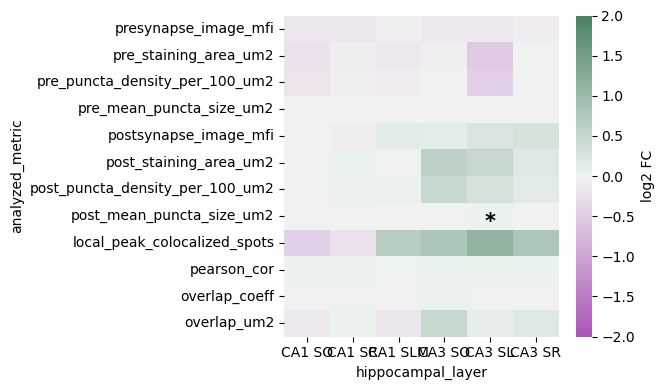

In [29]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(df_wide_vglut1_log2_fc_ordered, 
            cmap= sns.diverging_palette(300, 145, s=60, as_cmap=True),  
            center=0,  
            annot=False,  
            cbar_kws={'label': 'log2 FC'},
            ax=ax,
            vmin=-2,
            vmax=2)

significance_threshold = 0.05


for i in range(df_wide_vglut1_p_value_ordered.shape[0]):
    for j in range(df_wide_vglut1_p_value_ordered.shape[1]):
        if df_wide_vglut1_p_value_ordered.iloc[i, j] < significance_threshold:  # Use .iloc for DataFrame
            ax.text(j + 0.5, i + 0.7, '*',
                   ha='center', va='center',
                   color='black', fontsize=15, fontweight='bold')

plt.tight_layout()
if experiment == "crispr": 
    plt.savefig(f"{protein}_vglut1_heatmap_plot.svg", format='svg')
elif experiment == "oe": 
    plt.savefig(f"{protein}_oe_vglut1_heatmap_plot.svg", format='svg')
plt.show()

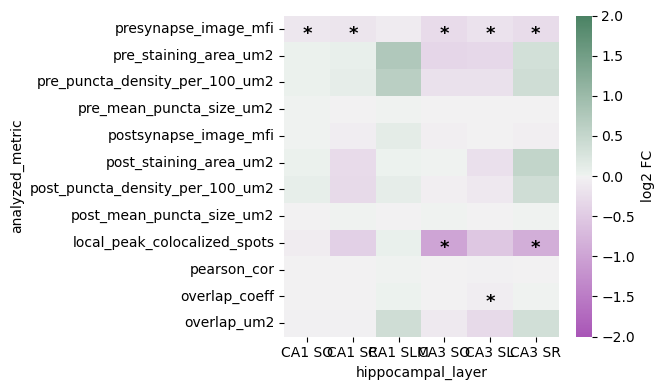

In [30]:
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(df_wide_vgat_log2_fc_ordered, 
            cmap=sns.diverging_palette(300, 145, s=60, as_cmap=True),  
            center=0,  
            annot=False,  
            cbar_kws={'label': 'log2 FC'},
            ax=ax,
            vmin=-2,
            vmax=2)

significance_threshold = 0.05

for i in range(df_wide_vgat_p_value_ordered.shape[0]):
    for j in range(df_wide_vgat_p_value_ordered.shape[1]):
        if df_wide_vgat_p_value_ordered.iloc[i, j] < significance_threshold:  # Use .iloc for DataFrame
            ax.text(j + 0.5, i + 0.7, '*',
                   ha='center', va='center',
                   color='black', fontsize=13, fontweight='bold')

plt.tight_layout()
if experiment == "crispr": 
    plt.savefig(f"{protein}_vgat_heatmap_plot.svg", format='svg')
elif experiment == "oe":
    plt.savefig(f"{protein}_oe_vgat_heatmap_plot.svg", format='svg') 
plt.show()
